<ipython-input-5-935627e82187>:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_paises.loc[:, 'year'] = df_paises['rank_date'].dt.year


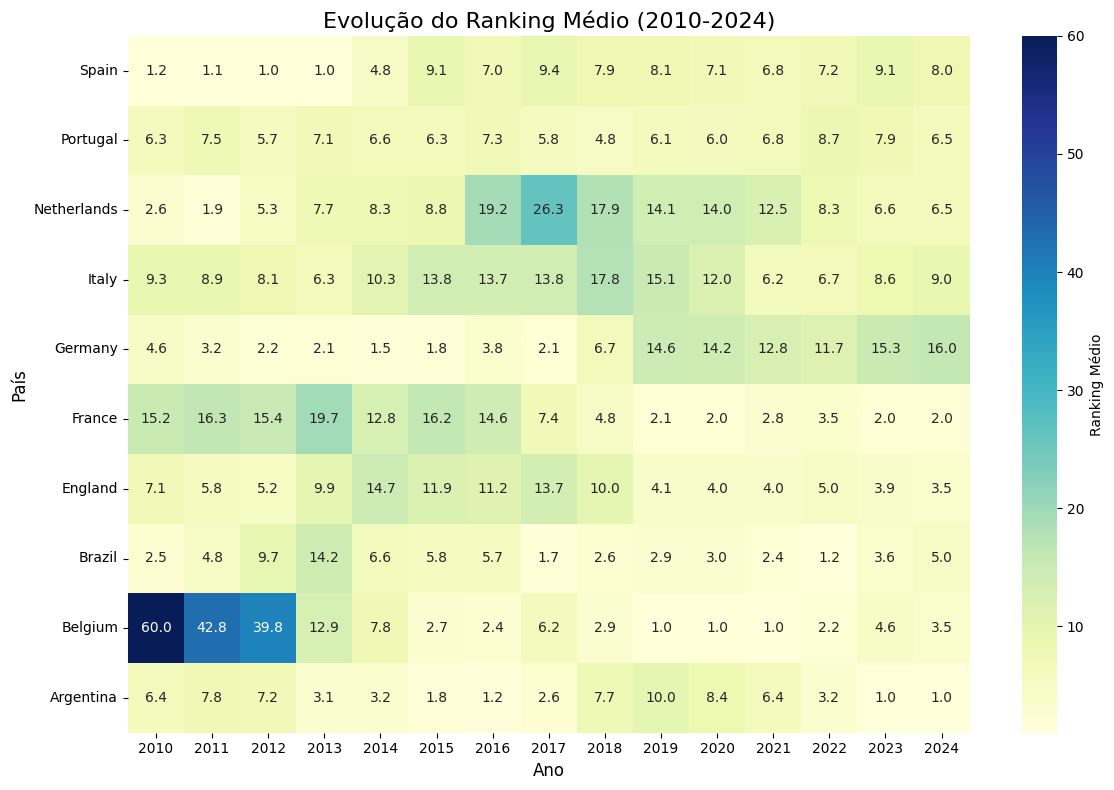

In [5]:
#3. Pesquisar a forma de criar um mapa de calor acerca da evolução do ranking de 10 países selecionados pelo usuário. Em seguida, elaborar seu código em Python para plotar tal mapa.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path = "fifa_ranking-2024-04-04.csv"
df = pd.read_csv(file_path)

df['rank_date'] = pd.to_datetime(df['rank_date'])

paises = ["Brazil", "Germany", "Argentina", "France", "Italy",
          "Spain", "England", "Netherlands", "Portugal", "Belgium"]

df_paises = df[(df['country_full'].isin(paises)) &
               (df['rank_date'].dt.year >= 2010) &
               (df['rank_date'].dt.year <= 2024)]

df_paises.loc[:, 'year'] = df_paises['rank_date'].dt.year

df_media_ranking = df_paises.groupby(['country_full', 'year'])['rank'].mean().unstack()

plt.figure(figsize=(12, 8))
sns.heatmap(df_media_ranking, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Ranking Médio'})
plt.title("Evolução do Ranking Médio (2010-2024)", fontsize=16)
plt.xlabel("Ano", fontsize=12)
plt.ylabel("País", fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()